# 📓 Notebook 3 — Exploratory Data Analysis
### AirSense AI — Intelligent Urban Air Quality Forecasting & Decision Support System

**Purpose of this notebook**

Visually explore the AirSense Feature Cube (`airsense_cube.csv`) produced in
Notebook 2. The goal is to build intuition about how PM2.5 and its related
variables behave over time — before we move to formal statistical testing
in Notebook 4.

We look at:
- Trends over time for each pollutant and weather variable
- Daily, weekly, and seasonal cycles
- A correlation heatmap across all numeric variables
- Missing values and outliers, now in visual context
- Rolling averages to smooth out hourly noise

**A markdown "Observation" cell follows every figure** — write down what you
actually see. These notes directly feed Notebook 4 (Statistical Analysis),
where we test the patterns spotted here formally.

---


## 1. Imports & setup

In [7]:
import sys
!{sys.executable} -m pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [8]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("pandas:", pd.__version__, "| matplotlib:", plt.matplotlib.__version__, "| seaborn:", sns.__version__)

pandas: 2.3.3 | matplotlib: 3.11.0 | seaborn: 0.13.2


## 2. Load the AirSense Feature Cube

In [9]:
PROJECT_ROOT = Path(r"C:\Users\pc\Desktop\AirSenseAI")
CUBE_PATH = PROJECT_ROOT / "data" / "processed" / "airsense_cube.csv"

print("Cube file:", CUBE_PATH, "| exists:", CUBE_PATH.exists())

Cube file: C:\Users\pc\Desktop\AirSenseAI\data\processed\airsense_cube.csv | exists: True


In [10]:
df = pd.read_csv(CUBE_PATH)

# The 'time' column has mixed UTC offsets (e.g. -05:00 in winter, -04:00 in
# summer, due to DST) because it was saved with America/New_York local time.
# pandas' automatic parse_dates can silently fail on mixed offsets and leave
# the column as plain strings, so we parse it explicitly here instead.
df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert('America/New_York')

print("time dtype:", df['time'].dtype)
print("Shape:", df.shape)
df.head()

time dtype: datetime64[ns, America/New_York]
Shape: (17568, 17)


,time,PM10,PM2.5,O3,NO2,Temperature,Relative Humidity,Wind Speed,Wind Direction,Precipitation,Cloud Cover,Hour,Weekday,Month,Weekend,ISO Week,Season
0,2023-12-31 19:00:00-05:00,27.8,19.3,0,56.8,3.8,65,5.7,235,0.0,65,19,Sunday,12,True,52,Winter
1,2023-12-31 20:00:00-05:00,31.3,21.7,0,55.6,3.8,60,6.0,245,0.0,99,20,Sunday,12,True,52,Winter
2,2023-12-31 21:00:00-05:00,35.5,24.6,0,54.0,3.1,65,6.8,238,0.0,96,21,Sunday,12,True,52,Winter
3,2023-12-31 22:00:00-05:00,40.0,27.8,0,52.5,2.6,68,8.4,245,0.0,73,22,Sunday,12,True,52,Winter
4,2023-12-31 23:00:00-05:00,43.9,30.5,0,51.5,1.9,74,6.3,246,0.0,100,23,Sunday,12,True,52,Winter


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype                           
---  ------             --------------  -----                           
 0   time               17568 non-null  datetime64[ns, America/New_York]
 1   PM10               17568 non-null  float64                         
 2   PM2.5              17568 non-null  float64                         
 3   O3                 17568 non-null  int64                           
 4   NO2                17568 non-null  float64                         
 5   Temperature        17568 non-null  float64                         
 6   Relative Humidity  17568 non-null  int64                           
 7   Wind Speed         17568 non-null  float64                         
 8   Wind Direction     17568 non-null  int64                           
 9   Precipitation      17568 non-null  float64                         
 10  Cloud Cove

## 3. Missing values and duplicates (visual confirmation)

Notebook 2 already confirmed this numerically, but a quick heatmap makes it
immediately obvious if anything is off before we start plotting trends.

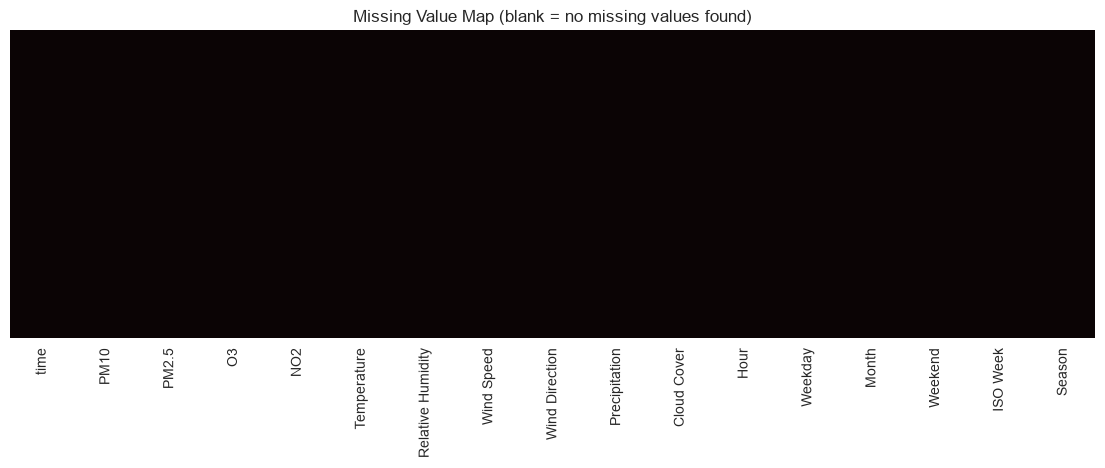

Total missing values across all columns: 0
Duplicate rows: 0


In [12]:
plt.figure(figsize=(14, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="mako")
plt.title("Missing Value Map (blank = no missing values found)")
plt.show()

print("Total missing values across all columns:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

**Observation:** _(fill this in after running the cell above)_
Note whether the heatmap is fully blank (no missing data) and the duplicate
count is 0, confirming Notebook 2's cleaning held up.

## 4. Pollutant trends over time

Full 2-year view of each pollutant. At this scale, individual daily
fluctuations blur together — we're looking for **long-term trend and
seasonality**, not daily detail.

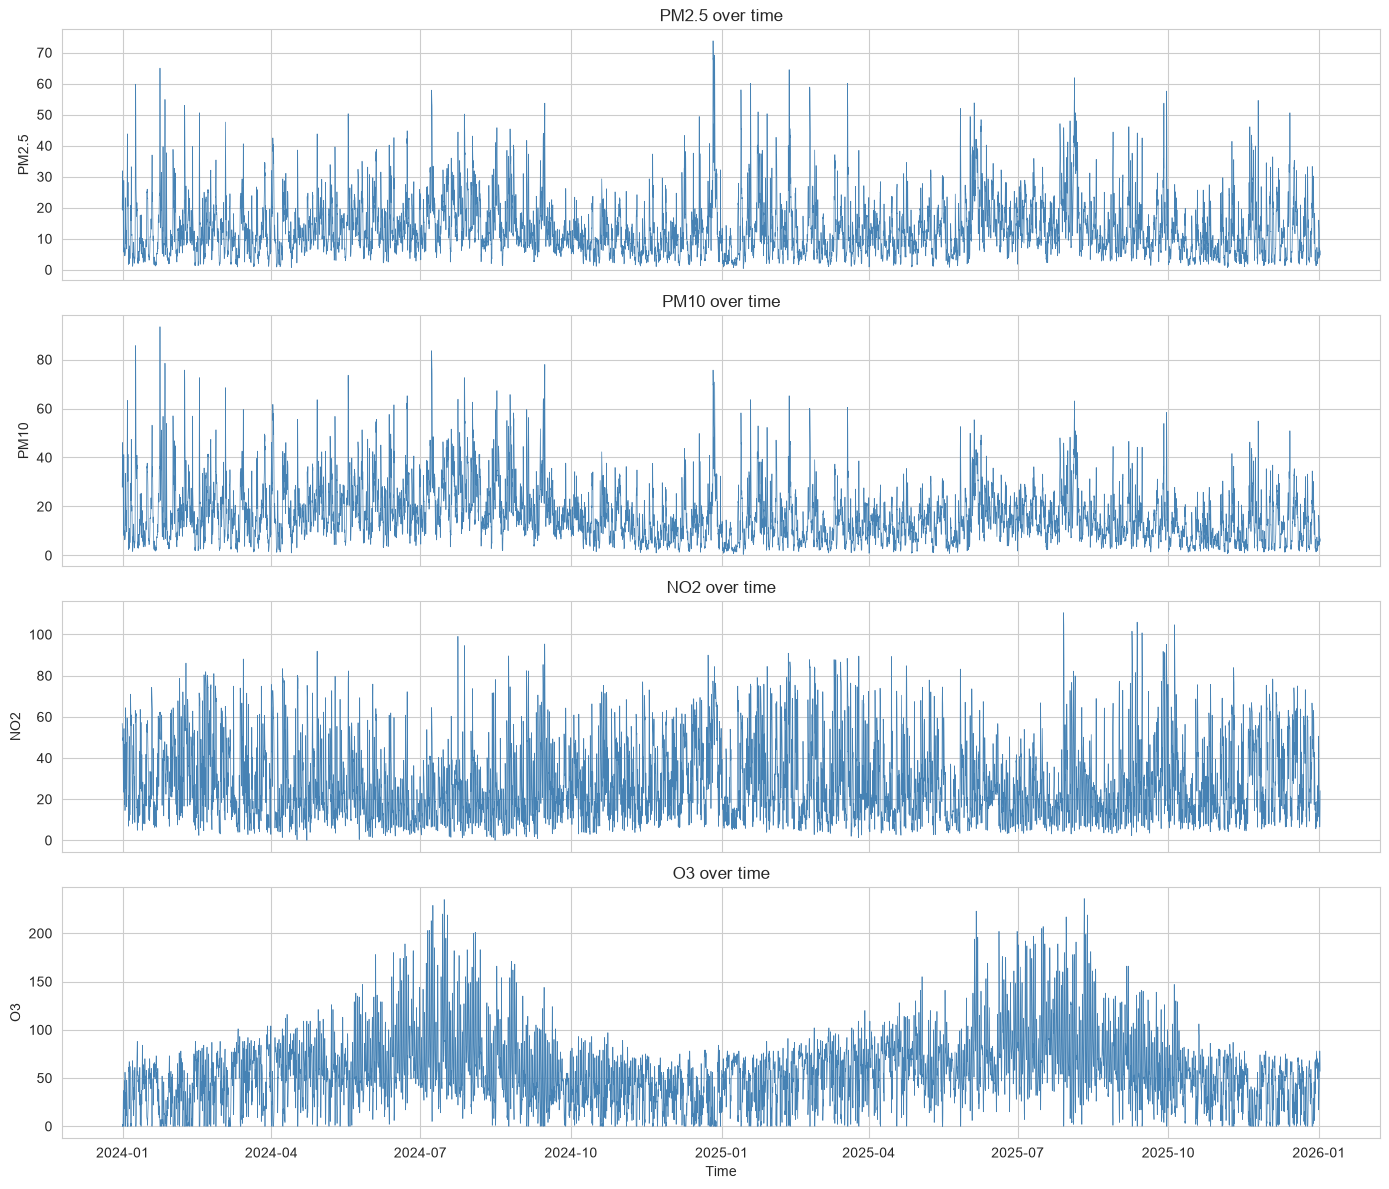

In [13]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'O3']

fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, pollutants):
    ax.plot(df['time'], df[col], linewidth=0.5, color='steelblue')
    ax.set_ylabel(col)
    ax.set_title(f"{col} over time")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note any visible seasonality (e.g. higher PM2.5 in winter from heating, or
higher O3 in summer from stronger sunlight/photochemical reactions), any
sudden spikes worth investigating (could be real pollution events or
outliers), and whether any pollutant shows a long-term upward/downward
trend across the 2 years.

## 5. Weather variable trends over time

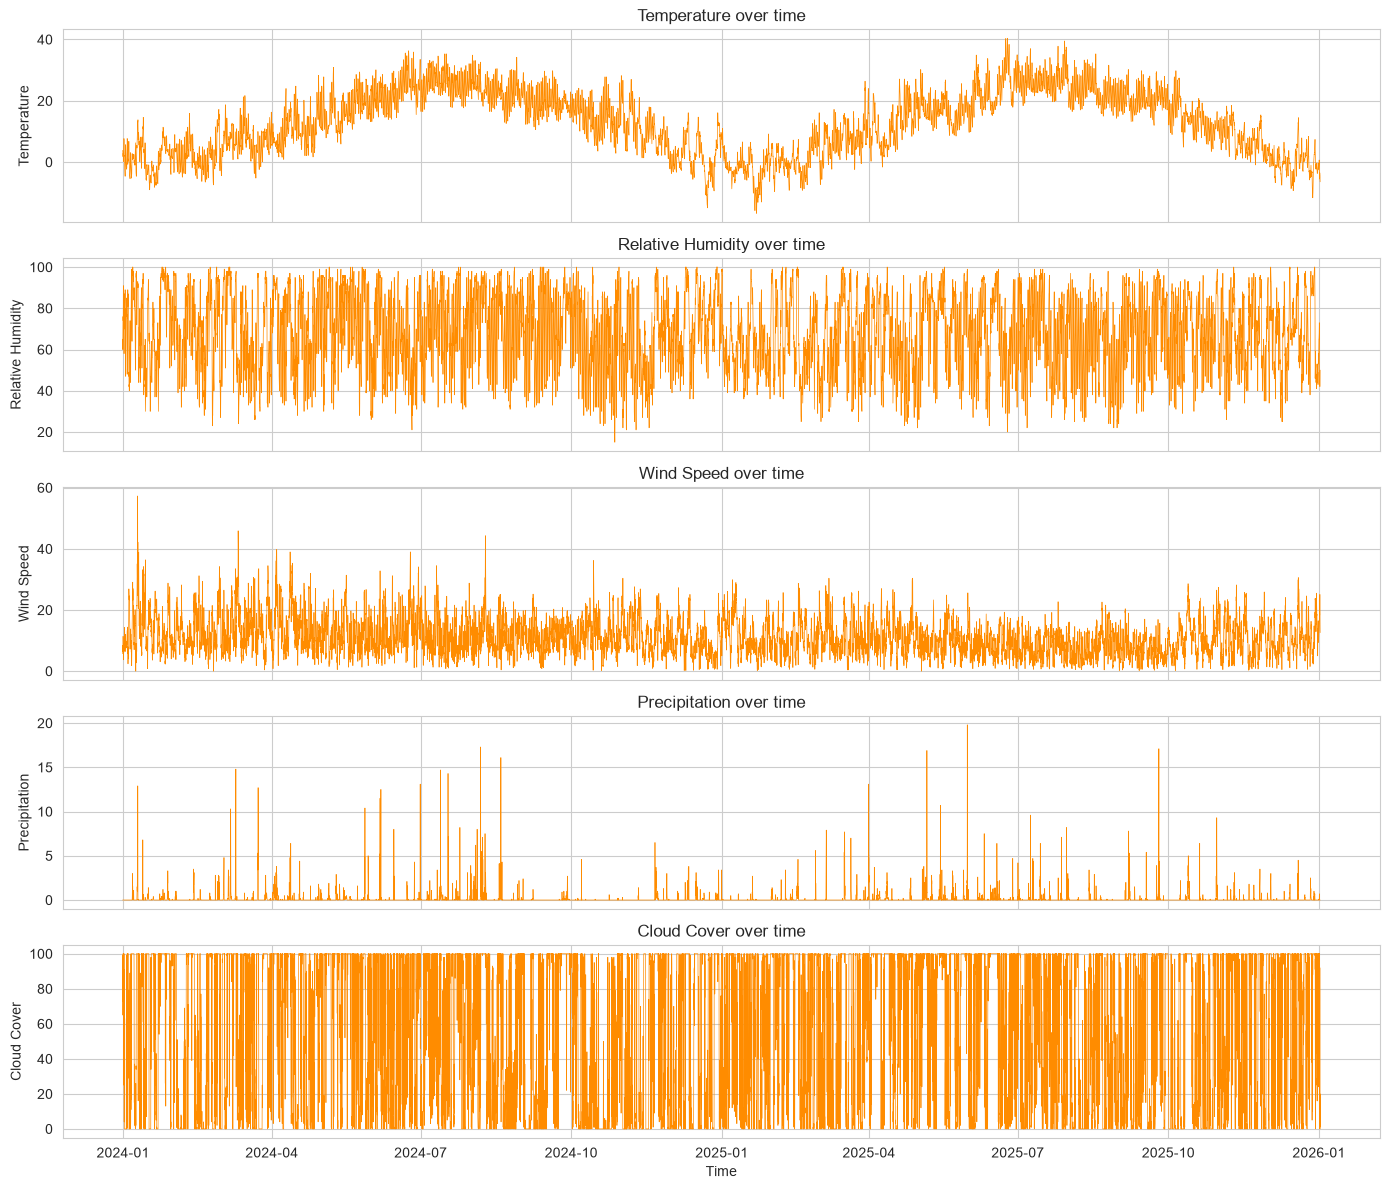

In [14]:
weather_vars = ['Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover']
weather_vars = [c for c in weather_vars if c in df.columns]

fig, axes = plt.subplots(len(weather_vars), 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, weather_vars):
    ax.plot(df['time'], df[col], linewidth=0.5, color='darkorange')
    ax.set_ylabel(col)
    ax.set_title(f"{col} over time")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Temperature should show a clear seasonal sine-wave pattern (this is a good
sanity check that the data itself is trustworthy). Note anything about
precipitation and cloud cover patterns, and whether wind speed looks fairly
stable or has notable spikes.

Reminder: `Surface Pressure` is not present in this dataset, so it's excluded
from this and all later analysis.

## 6. Daily cycle — average PM2.5 by hour of day

Averaging across all days lets us see the typical within-day pattern,
smoothing out day-to-day noise. This is where rush-hour effects should show
up, if they exist.

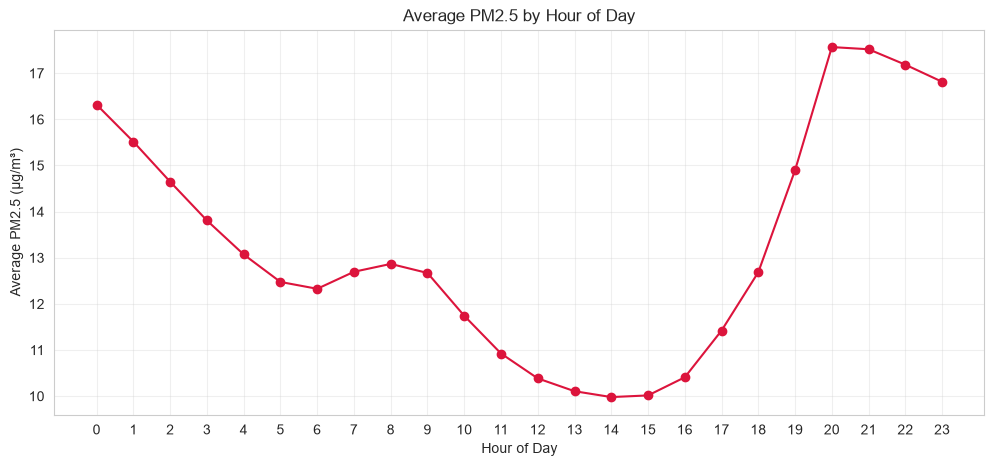

In [15]:
hourly_avg = df.groupby('Hour')['PM2.5'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='crimson')
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.title("Average PM2.5 by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** _(fill this in after running the cell above)_
Look for two peaks around typical morning and evening rush hours, or a
different pattern entirely. This directly informs whether "Hour" is a
useful predictive feature in later modeling.

## 7. Weekly cycle — average PM2.5 by day of week

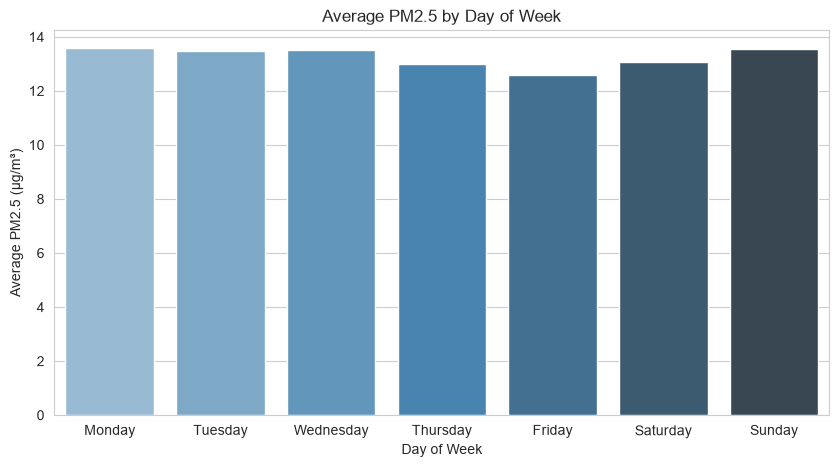

In [16]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = df.groupby('Weekday')['PM2.5'].mean().reindex(weekday_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values, hue=weekday_avg.index,
            palette="Blues_d", legend=False)
plt.xlabel("Day of Week")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.title("Average PM2.5 by Day of Week")
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note whether weekdays show noticeably higher PM2.5 than weekends (which
would suggest traffic/commuting is a driver), or whether the pattern is flat
across the week.

## 8. Seasonal trends — average PM2.5 by season

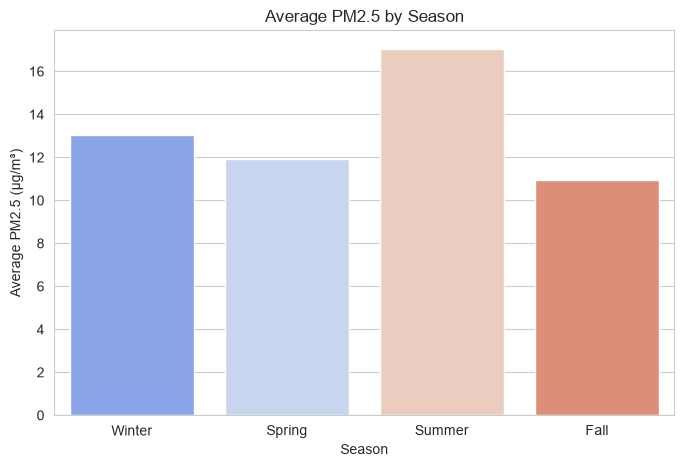

In [17]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_avg = df.groupby('Season')['PM2.5'].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_avg.index, y=season_avg.values, hue=season_avg.index,
            palette="coolwarm", legend=False)
plt.xlabel("Season")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.title("Average PM2.5 by Season")
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note which season has the highest average PM2.5 — in many cities this is
winter (heating, temperature inversions trapping pollutants close to the
ground) but confirm this holds for your actual data rather than assuming it.

## 9. Correlation heatmap

How strongly each numeric variable relates to PM2.5 and to each other. This
is a first visual pass — Notebook 4 will follow up with formal statistical
tests (Pearson, Spearman, Granger causality) rather than relying on this
heatmap alone.

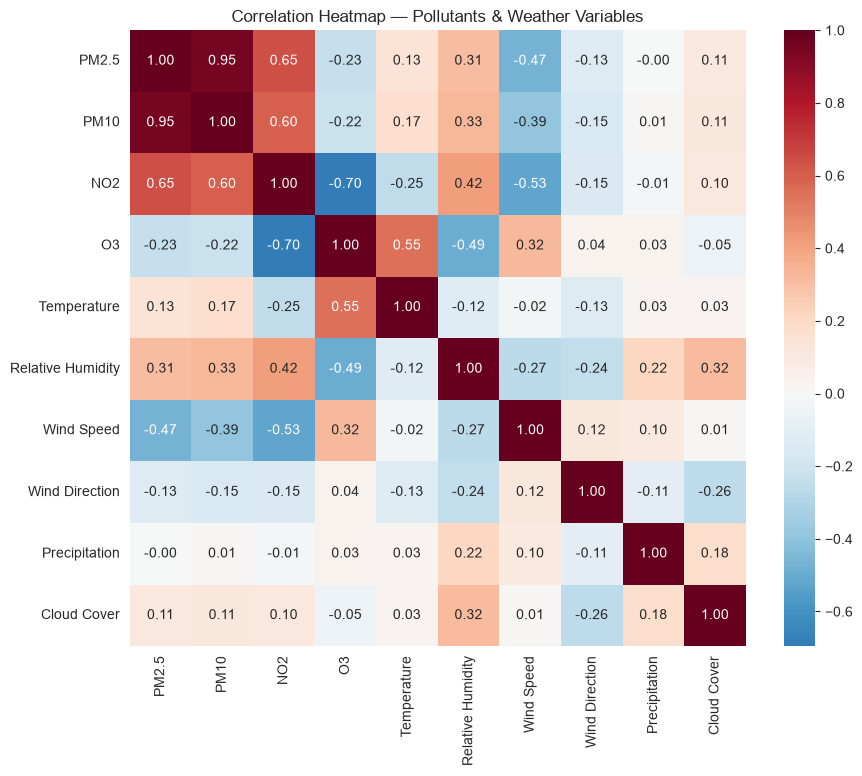

In [18]:
numeric_cols = ['PM2.5', 'PM10', 'NO2', 'O3', 'Temperature',
                'Relative Humidity', 'Wind Speed', 'Wind Direction',
                'Precipitation', 'Cloud Cover']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Heatmap — Pollutants & Weather Variables")
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note which weather variables correlate most strongly (positively or
negatively) with PM2.5. Strong correlation here doesn't prove causation —
that's exactly what Notebook 4's Granger causality tests will help clarify.

## 10. Outliers in visual context

Notebook 2 flagged outlier candidates using mean ± 3 std. Here we plot PM2.5
over time with those flagged points highlighted, so we can judge whether
they look like real events (e.g. a multi-hour pollution spike) or likely
sensor errors (e.g. a single isolated impossible value).

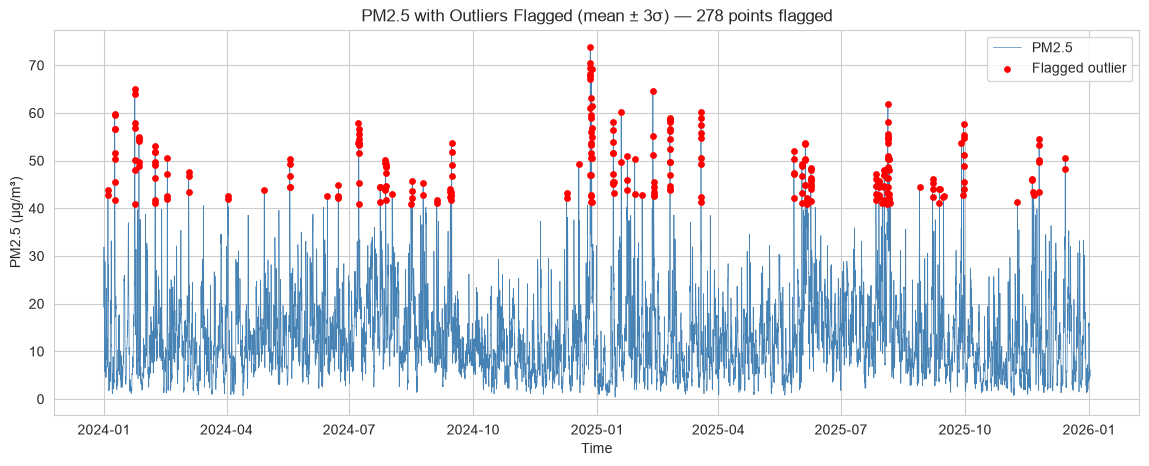

In [19]:
mean, std = df['PM2.5'].mean(), df['PM2.5'].std()
lower, upper = mean - 3 * std, mean + 3 * std
outlier_mask = (df['PM2.5'] < lower) | (df['PM2.5'] > upper)

plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['PM2.5'], linewidth=0.5, color='steelblue', label='PM2.5')
plt.scatter(df.loc[outlier_mask, 'time'], df.loc[outlier_mask, 'PM2.5'],
            color='red', s=15, label='Flagged outlier', zorder=5)
plt.xlabel("Time")
plt.ylabel("PM2.5 (μg/m³)")
plt.title(f"PM2.5 with Outliers Flagged (mean ± 3σ) — {outlier_mask.sum()} points flagged")
plt.legend()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note whether flagged points cluster together in time (suggesting a real
sustained pollution event, like wildfire smoke or a holiday fireworks spike)
or appear as isolated single-hour spikes (more likely sensor noise). This
judgment call determines whether Notebook 5 (Feature Engineering) should cap,
remove, or keep these values.

## 11. Rolling averages — smoothing out hourly noise

A 24-hour rolling average reveals the underlying trend by removing hour-to-
hour noise, making longer-term patterns (weekly, seasonal) much easier to see
than in the raw hourly plot from Section 4.

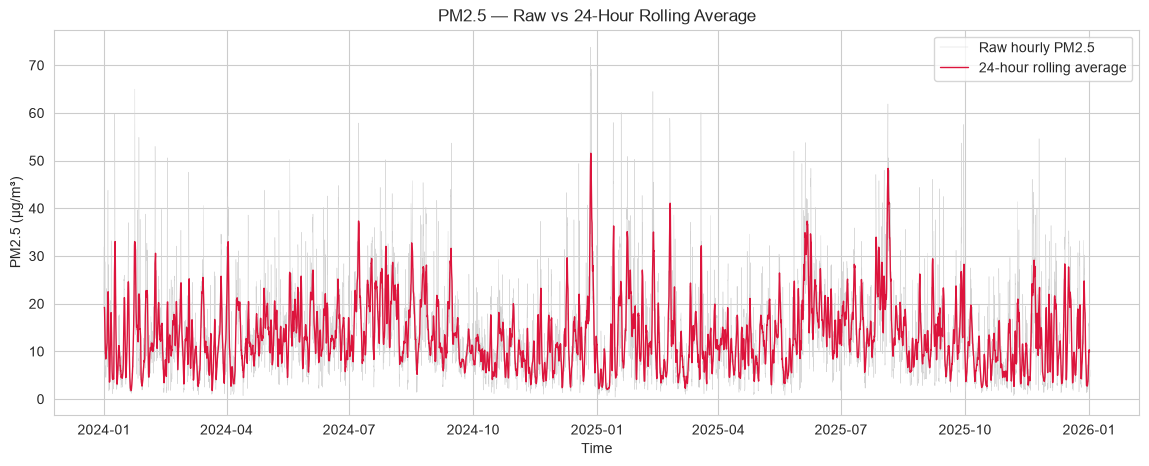

In [20]:
df['PM2.5_rolling_24h'] = df['PM2.5'].rolling(window=24, center=True).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['PM2.5'], linewidth=0.3, color='lightgray', label='Raw hourly PM2.5')
plt.plot(df['time'], df['PM2.5_rolling_24h'], linewidth=1, color='crimson', label='24-hour rolling average')
plt.xlabel("Time")
plt.ylabel("PM2.5 (μg/m³)")
plt.title("PM2.5 — Raw vs 24-Hour Rolling Average")
plt.legend()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note how much cleaner the seasonal pattern looks once hourly noise is
smoothed out. This rolling average is also a strong candidate feature for
Notebook 5 (Feature Engineering) — a `PM2.5_rolling_24h` column is listed
there for exactly this reason.

## 12. Summary

Through this EDA pass we've visually explored:

- ✅ Confirmed no missing values or duplicates remain in the cube
- ✅ Long-term trends for all 4 pollutants and all weather variables
- ✅ Daily cycle (by hour) and weekly cycle (by weekday) for PM2.5
- ✅ Seasonal pattern for PM2.5
- ✅ Correlation heatmap across all numeric variables
- ✅ Outlier candidates shown in time-series context, not just as a number
- ✅ 24-hour rolling average, revealing the underlying trend more clearly

**Next step → Notebook 4 (Statistical Analysis):**
Move from visual impressions to formal tests — Pearson/Spearman correlation,
ADF stationarity test, cross-correlation to find optimal lags between weather
and PM2.5, and Granger causality to determine which weather variables
actually help predict PM2.5 rather than just correlating with it.